# Redesigned Assignment: Metrics Analysis, Classification, and Density Estimation




In [1]:
student_number = "402102392"   
Name = "Niloofar"             
Last_Name = "Mahmoodi"       

## Setup and Required Libraries

Run the following cells before starting the assignment.

**Hint:**  
If a package is missing, install it first and restart the kernel if needed.


In [2]:
# Core libraries
import numpy as np
import pandas as pd


In [3]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# Scikit-learn datasets and utilities
from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


In [6]:
# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture


In [7]:
# Metrics and mathematical utilities
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from scipy.stats import norm, multivariate_normal


# Part 1: Loading Iris and Building a DataFrame

## Question 1(4pts)

Load the Iris dataset using `load_iris`. Then create a DataFrame containing:

1. the four original features;
2. a `target` column;
3. a `species_name` column showing the species name of each sample.

Then report:

- the number of samples in each class;
- the mean of each feature for each species;
- the first five rows of the DataFrame.

### Hint
Use `iris.feature_names`, `iris.target`, and `iris.target_names`.


In [14]:
# TODO 1.1: Load the Iris dataset
Iris =load_iris()

In [15]:
# TODO 1.2: Create a clean DataFrame
Iris_DataFrame= pd.DataFrame(Iris.data, columns = Iris.feature_names)
Iris_DataFrame["target"]= Iris.target
Iris_DataFrame["species_name"] = Iris.target_names[Iris_DataFrame["target"]]
Iris_DataFrame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [12]:
# TODO 1.3: Report class counts
class_counts =Iris_DataFrame.groupby("species_name").size().reset_index(name = "class_counts")
print(class_counts)

  species_name  class_counts
0       setosa            50
1   versicolor            50
2    virginica            50


In [14]:
# TODO 1.4: Report mean of each feature per species
feature_means = Iris_DataFrame.groupby("species_name")[Iris.feature_names].mean().reset_index()
print("Mean of each feature per species:")
print(feature_means.to_string(index=False))

Mean of each feature per species:
species_name  sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
      setosa              5.006             3.428              1.462             0.246
  versicolor              5.936             2.770              4.260             1.326
   virginica              6.588             2.974              5.552             2.026


# Part 2: Visual Feature Analysis

## Question 2(3pts)

Draw a separate histogram for each feature, using different colors for different flower species. Then explain which features are more useful for separating the classes and why.

### Hint
Features with less overlap between class distributions are usually more useful for classification.


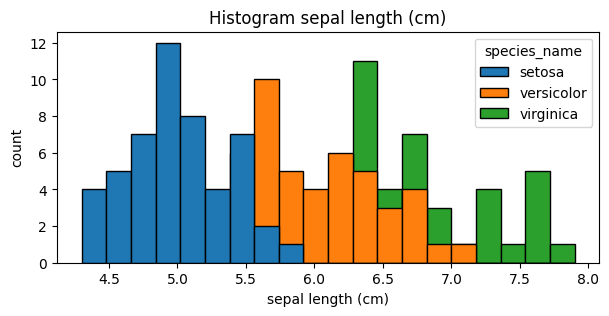

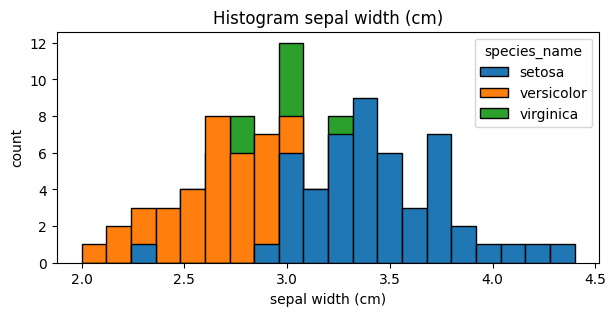

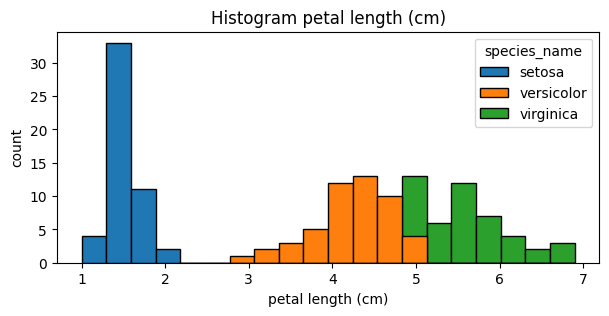

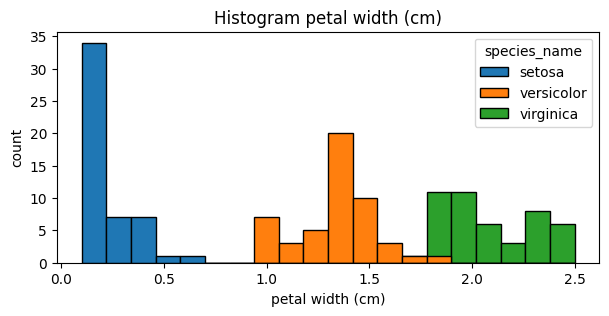

In [15]:
# TODO 2.1: Draw histograms for all features
for feature in Iris.feature_names:
    plt.figure(figsize =(7, 3))
    sns.histplot(
        data = Iris_DataFrame,
        x = feature,
        hue= "species_name",
        alpha = 1,
        bins =20
    )
    plt.title(f"Histogram {feature}")
    plt.xlabel(feature)
    plt.ylabel("count")
    plt.show()

### explain which features are more useful for separating the classes and why
<div dir="rtl" align="right">
برای جدا کردن کلاس‌ ها petal length و petal width با توجه به هیستوگرام ها ویژگی‌ های مفیدتری برای طبقه‌ بندی هستند.  
در این دو ویژگی تقریبا به‌ خوبی گونه های Iris به خصوص setosa قابل تفکیک است.
در مقابل sepal length و sepal width هم‌ پوشانی بیشتری بین گونه‌ ها دارند بنابراین برای تفکیک کلاس‌ ها ضعیف‌تر هستند.  
پس در نتیجه petal length و petal width بهترین ویژگی‌ ها برای طبقه‌ بندی هستند.
</div>

## Question 3(3pts)

Using a `pairplot`, choose the two features that you think have the strongest class-separation power. Then draw a scatter plot using only those two features and explain whether the classes can be separated by a linear decision boundary.

### Hint
In the pairplot, look for feature pairs where points from different classes form more clearly separated clusters.


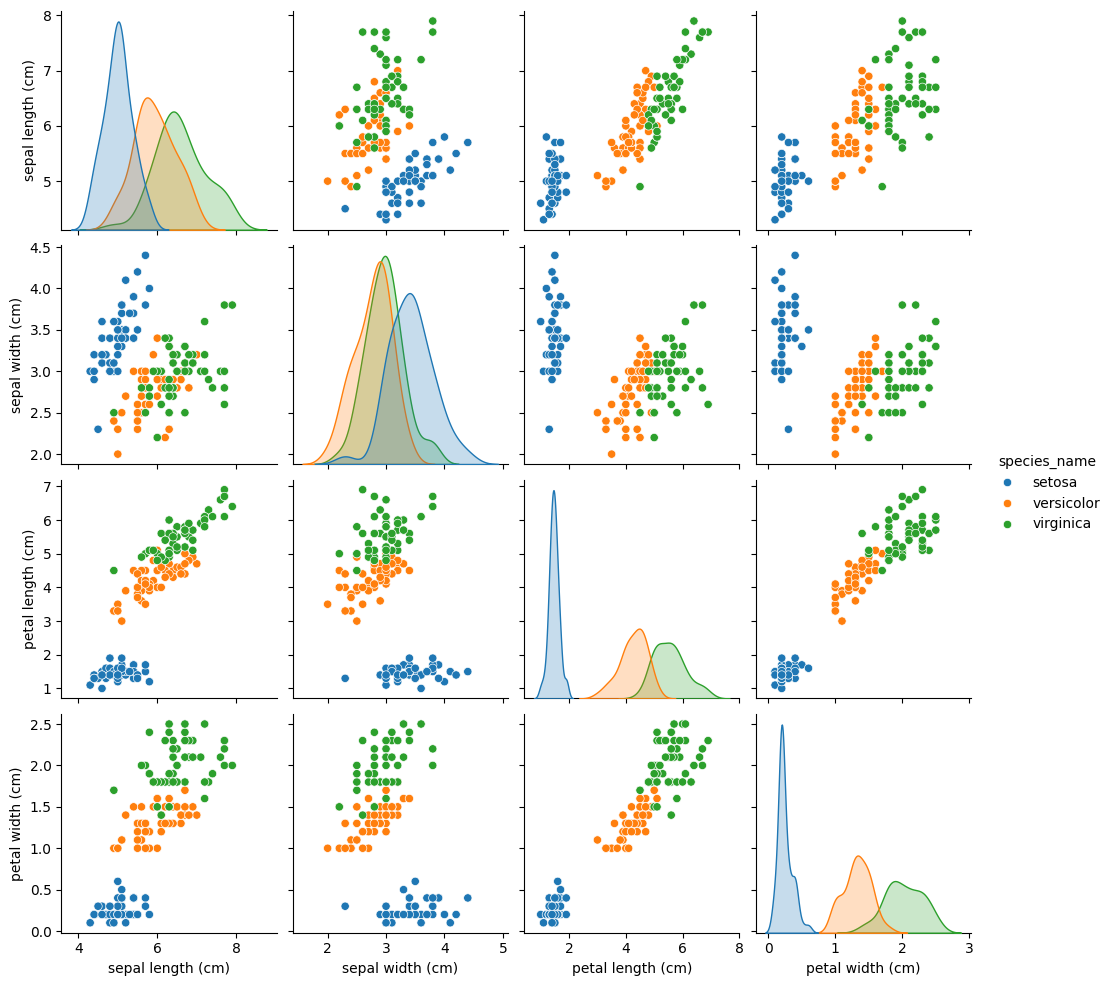

In [17]:
# TODO 3.1: Draw a pairplot
sns.pairplot(
    Iris_DataFrame[Iris.feature_names + ["species_name"]],
    hue ="species_name",
)
plt.show()

In [18]:
# TODO 3.2: Select two visually strong features
x = "petal length (cm)"
y = "petal width (cm)"

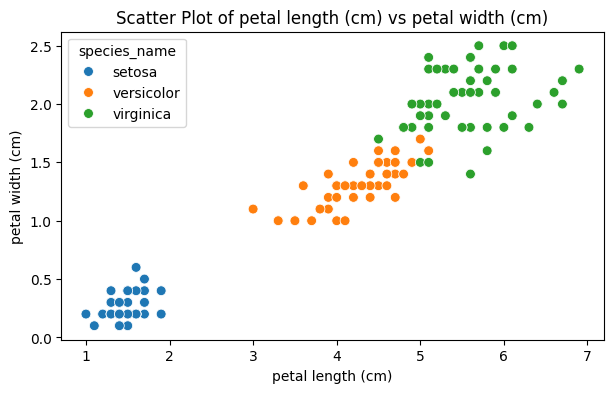

In [19]:
# TODO 3.3: Draw a scatter plot using the selected features
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=Iris_DataFrame,
    x=x,
    y=y,
    s=50,
    hue= "species_name"
)
plt.title(f"Scatter Plot of {x} vs {y}")
plt.xlabel(x)
plt.ylabel(y)
plt.show()

### explain whether the classes can be separated by a linear decision boundary
<div dir="rtl" align="right">
با توجه به نمودار دو ویژگی petal length (cm) و petal width (cm) بهترین قدرت را برای جدا کردن کلاس‌ ها دارند. چون  کلاس‌ ها تا حد خوبی با یک مرز تصمیم‌ گیری خطی قابل جدا شدن هستند مخصوصا گونه‌ ی setosa. 
<div>

## Question 4(5pts)

For each feature and each class, compute the following values:

- median
- Q1
- Q3
- IQR

Then draw a boxplot for each feature and compare the numerical results with the plots.

### Hint
Use `groupby` and `quantile`.

The IQR is defined as:

\[
IQR = Q3 - Q1
\]


In [21]:
# TODO 4.1: Compute median, Q1, Q3, and IQR
values = (
    Iris_DataFrame
    .groupby("species_name")[Iris.feature_names]
    .quantile([0.25, 0.5, 0.75])  
    .unstack(level= -1)             
)
median = values.xs(0.5,  level= 1, axis= 1)
Q1 = values.xs(0.25, level =1, axis=1)
Q3 = values.xs(0.75, level =1, axis=1)

S = []
for i in Iris_DataFrame["species_name"].unique():
    for j in Iris.feature_names:
        m1 = median.loc[i,j]
        m2 = Q1.loc[i,j]
        m3 = Q3.loc[i, j]
        m4 = m3 - m2
        S.append({
            "species_name": i,
            "feature" :j,
            "Median": m1,
            "Q1": m2,
            "Q3":m3,
            "IQR": m4
        }
        )
print(pd.DataFrame(S).to_string(index=False))

species_name           feature  Median    Q1    Q3   IQR
      setosa sepal length (cm)    5.00 4.800 5.200 0.400
      setosa  sepal width (cm)    3.40 3.200 3.675 0.475
      setosa petal length (cm)    1.50 1.400 1.575 0.175
      setosa  petal width (cm)    0.20 0.200 0.300 0.100
  versicolor sepal length (cm)    5.90 5.600 6.300 0.700
  versicolor  sepal width (cm)    2.80 2.525 3.000 0.475
  versicolor petal length (cm)    4.35 4.000 4.600 0.600
  versicolor  petal width (cm)    1.30 1.200 1.500 0.300
   virginica sepal length (cm)    6.50 6.225 6.900 0.675
   virginica  sepal width (cm)    3.00 2.800 3.175 0.375
   virginica petal length (cm)    5.55 5.100 5.875 0.775
   virginica  petal width (cm)    2.00 1.800 2.300 0.500


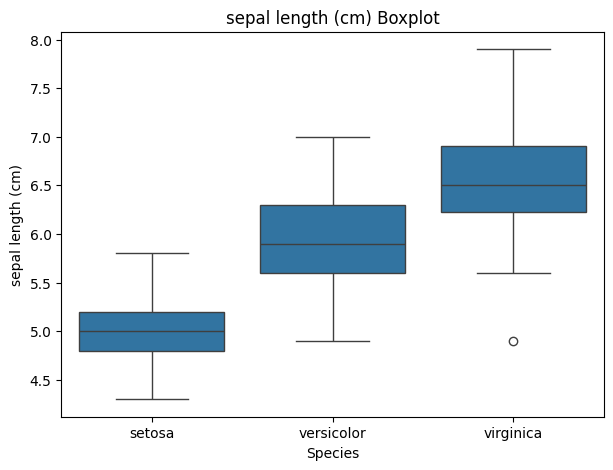

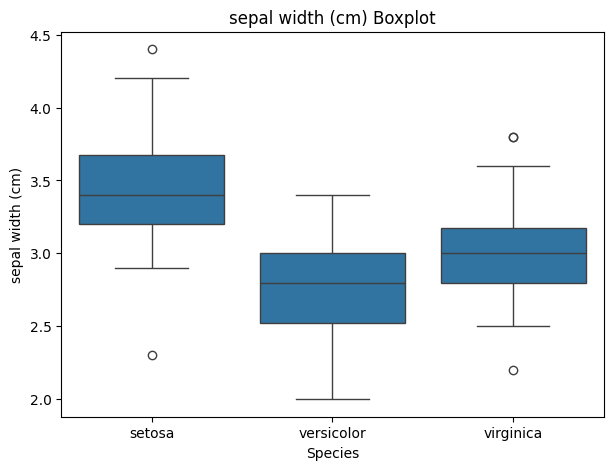

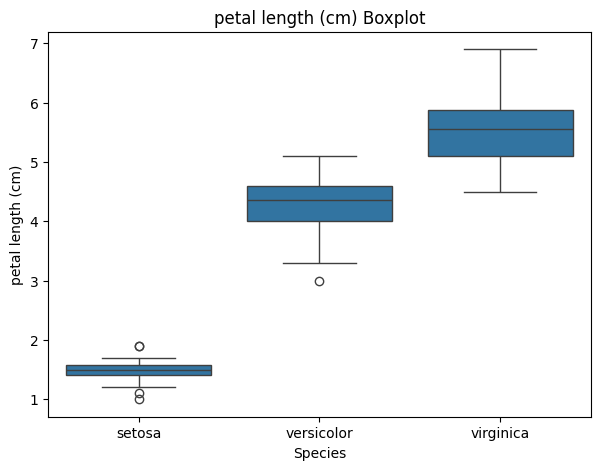

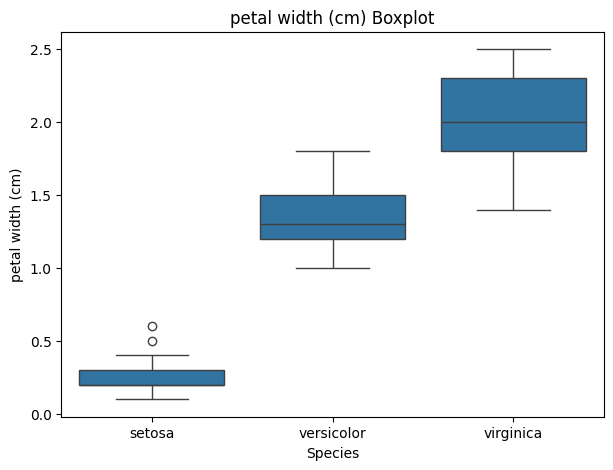

In [22]:
# TODO 4.2: Draw boxplots for all features
for j in Iris.feature_names:
    plt.figure(figsize=(7, 5))
    sns.boxplot(
        data= Iris_DataFrame,
        x ="species_name",
        y =j
    )
    plt.title(f"{j} Boxplot")
    plt.xlabel("Species")
    plt.ylabel(j)
    plt.show()

### compare the numerical results with the plots
<div dir="rtl" align="right">
مقادیر  median، Q1، Q3 و IQR با boxplot ها کاملا هماهنگ هستند. median همان خط وسط جعبه است و Q1 و Q3 لبه پایین و بالای جعبه را نشان می‌دهند وIQR هم برابر ارتفاع جعبه است.
<div>

# Part 3: Data Splitting with a DataLoader Class

## Question 5(10pts)

Implement a class named `IrisDataLoader` with the following capabilities:

1. receive train, validation, and test ratios from the user;
2. check that the sum of the ratios is equal to 1;
3. perform stratified splitting;
4. print class distributions before and after splitting;
5. return train, validation, and test data.

### Hint
To obtain separate validation and test sets, first split off the training set, then split the remaining data into validation and test sets.


In [34]:
# TODO 5.1: Define the DataLoader class
from sklearn.model_selection import train_test_split

class IrisDataLoader:
    def __init__(users, data, target, train_ratio, validation_ratio, test_ratio):
        users.data = data
        users.target = target
        users.train_ratio = train_ratio
        users.validation_ratio = validation_ratio
        users.test_ratio = test_ratio

        if round(train_ratio + validation_ratio + test_ratio, 5) != 1:
            raise ValueError("Ratios must sum to 1.")

    def split_data(users):
        drop_columns = [users.target]

        if "target" in users.data.columns and "target" not in drop_columns:
            drop_columns.append("target")

        if "species_name" in users.data.columns and "species_name" not in drop_columns:
            drop_columns.append("species_name")

        X = users.data.drop(columns=drop_columns)
        Y = users.data[users.target]
        print("Original class distribution")
        print(Y.value_counts(normalize=True))

        Xtrain, Xtemp, Ytrain, Ytemp = train_test_split(
            X, Y, test_size=1 - users.train_ratio, stratify=Y
        )

        Xvalidation, Xtest, Yvalidation, Ytest = train_test_split(
            Xtemp,
            Ytemp,
            test_size=users.test_ratio / (users.validation_ratio + users.test_ratio),
            stratify=Ytemp
        )

        print("\n Class Distribution After splitting Train")
        print(Ytrain.value_counts(normalize=True))
        print("\n Class Distribution After splitting Validation")
        print(Yvalidation.value_counts(normalize=True))
        print("\nClass Distribution After splitting Test")
        print(Ytest.value_counts(normalize=True))

        return Xtrain, Xvalidation, Xtest, Ytrain, Yvalidation, Ytest

In [244]:
# TODO 5.2: Create a DataLoader object
train_ratio = float(input("Enter train ratio: "))
validation_ratio = float(input("Enter validation ratio: "))
test_ratio = float(input("Enter test ratio: "))

Objects = IrisDataLoader(
    data=Iris_DataFrame,
    target= "species_name",
    train_ratio =train_ratio,
    validation_ratio=validation_ratio,
    test_ratio= test_ratio
)

In [245]:
# TODO 5.3: Split the data
Xtrain, Xvalidation, Xtest, Ytrain, Yvalidation, Ytest = Objects.split_data()

Original class distribution
species_name
setosa        0.333333
versicolor    0.333333
virginica     0.333333
Name: proportion, dtype: float64

 Class Distribution After splitting Train
species_name
versicolor    0.333333
setosa        0.333333
virginica     0.333333
Name: proportion, dtype: float64

 Class Distribution After splitting Validation
species_name
virginica     0.3750
versicolor    0.3125
setosa        0.3125
Name: proportion, dtype: float64

Class Distribution After splitting Test
species_name
versicolor    0.352941
setosa        0.352941
virginica     0.294118
Name: proportion, dtype: float64


In [246]:
# TODO 5.4: Check split shapes
print("Xtrain:", Xtrain.shape)
print("Xvalidation:", Xvalidation.shape)
print("Xtest:", Xtest.shape)
print("Ytrain:", Ytrain.shape)
print("Yvalidation:", Yvalidation.shape)
print("Ytest:", Ytest.shape)

Xtrain: (117, 4)
Xvalidation: (16, 4)
Xtest: (17, 4)
Ytrain: (117,)
Yvalidation: (16,)
Ytest: (17,)


# Part 4: Gaussian Naive Bayes from Scratch

## Question 6(10pts)

Implement a `Gaussian Naive Bayes` model from scratch. Then compare its result with `sklearn.naive_bayes.GaussianNB`.

Requirements:

1. compute the mean and variance of each feature for each class;
2. compute the prior probability of each class;
3. add a small `epsilon` value to the variance;
4. perform prediction using log-probabilities.

### Hint
To avoid numerical underflow, sum log-probabilities instead of multiplying probabilities.


In [247]:
# TODO 6.1: Define Custom Gaussian Naive Bayes
class CustomGaussianNB:
    def __init__(users, epsilon =1e-10):
        users.epsilon = epsilon
        users.classes1 = None
        users.mean1= None
        users.variance1 = None
        users.prior1 = None

    def F(users, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        users.classes1 = np.unique(y)
        nClasses = len(users.classes1)
        nFeatures = X.shape[1]
        users.mean1= np.zeros((nClasses, nFeatures))
        users.variance1 = np.zeros((nClasses, nFeatures))
        users.prior1 = np.zeros(nClasses)

        for i, class_label in enumerate(users.classes1):
            X_class = X[y == class_label]
            users.mean1[i, :] = np.mean(X_class, axis=0)
            users.variance1[i, :] =np.var(X_class, axis=0) + users.epsilon
            users.prior1[i] = X_class.shape[0] / X.shape[0]
        return users

    def likelihood(users, x, class_i):
        mean = users.mean1[class_i]
        variance = users.variance1[class_i]
        log_likelihood = -0.5 * np.sum( np.log(2 * np.pi * variance) + ((x - mean) ** 2) / variance)
        return log_likelihood

    def posterior(users, x):
        log_posteriors = []
        for class_i in range(len(users.classes1)):
            log_prior =np.log(users.prior1[class_i])
            log_likelihood = users.likelihood(x, class_i)
            log_posterior= log_prior + log_likelihood
            log_posteriors.append(log_posterior)

        return log_posteriors

    def predict(users, X):
        X = np.asarray(X)
        predicts =[]
        for x in X:
            log_posteriors =users.posterior(x)
            best_class_index = np.argmax(log_posteriors)
            predicts.append(users.classes1[best_class_index])

        return np.array(predicts)

In [248]:
# TODO 6.2: Train the custom model
custom_GaussianNB = CustomGaussianNB()
custom_GaussianNB.F(Xtrain, Ytrain)
custom_predicts= custom_GaussianNB.predict(Xtest)

print("Means:")
print(custom_GaussianNB.mean1)
print("Variances:")
print(custom_GaussianNB.variance1)
print("Priors:")
print(custom_GaussianNB.prior1)


Means:
[[5.00512821 3.42051282 1.44615385 0.24871795]
 [5.93589744 2.77948718 4.23076923 1.32564103]
 [6.66410256 3.         5.62564103 2.03589744]]
Variances:
[[0.1174096  0.14624589 0.0322288  0.01172913]
 [0.27358317 0.09701512 0.21854043 0.0383169 ]
 [0.43666009 0.11333333 0.33472715 0.07666009]]
Priors:
[0.33333333 0.33333333 0.33333333]


In [249]:
# TODO 6.3: Train sklearn GaussianNB
sklearn_GaussianNB= GaussianNB()
sklearn_GaussianNB.fit(Xtrain, Ytrain)
sklearn_predicts = sklearn_GaussianNB.predict(Xtest)

In [250]:
# TODO 6.4: Compare accuracies
Accuracy_C = accuracy_score(Ytest, custom_predicts)
Accuracy_S = accuracy_score(Ytest, sklearn_predicts)
print("Custom GaussianNB Accuracy:", Accuracy_C)
print("Sklearn GaussianNB Accuracy:", Accuracy_S)

Custom GaussianNB Accuracy: 1.0
Sklearn GaussianNB Accuracy: 1.0


# Part 5: Gaussian Bayes Classifier with Shared and Class-Specific Covariance

## Question 7(10pts)

Implement a Gaussian Bayes Classifier with two modes:

1. `covariance_type="tied"`: all classes share one covariance matrix;
2. `covariance_type="full"`: each class has its own covariance matrix.

Then compare the results with `LinearDiscriminantAnalysis` and `QuadraticDiscriminantAnalysis`.

### Hint
- The `tied` mode is similar to the idea behind LDA and produces linear decision boundaries.
- The `full` mode is similar to the idea behind QDA and can produce nonlinear decision boundaries.
- For numerical stability, add a small value to the diagonal of the covariance matrix.


In [251]:
# TODO 7.1: Define Gaussian Bayes Classifier
class GaussianBayesClassifier:
    def __init__(users, covariance_type ="tied", epsilon =1e-10):
        if covariance_type not in ("tied", "full"):
            raise ValueError("covariance_type must be 'tied' or 'full'")
        users.covariance_type = covariance_type
        users.epsilon = epsilon

    def F(users, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        users.classe1 = np.unique(y)
        n, m = X.shape
        users.mean1 = {}
        users.covariance1 = {}  
        users.priors1 = {}        
        users.tied_Covariance1 = None 

        for i in users.classe1:
            X_i =X[y == i]
            users.mean1[i] =X_i.mean(axis=0)
            users.priors1[i] = X_i.shape[0]/ n

        if users.covariance_type == "full":
            for i in users.classe1:
                X_i= X[y == i]
                center= X_i -users.mean1[i]
                covariance = (center.T @ center) /X_i.shape[0]
                covariance = covariance + users.epsilon* np.eye(m)
                users.covariance1[i]= covariance

        else:
            S = np.zeros((m, m))
            for i in users.classe1:
                X_i = X[y == i]
                center= X_i - users.mean1[i]
                S +=center.T @ center
            tied_covariance = S/ n
            tied_covariance = tied_covariance +users.epsilon * np.eye(m)
            users.tied_Covariance1 = tied_covariance
        return users

    def log_gaussian(users, x, mean, cov):
        sign, det = np.linalg.slogdet(cov)
        invert = np.linalg.inv(cov)
        diff = x - mean
        return -0.5 * (mean.shape[0] * np.log(2*np.pi) + det + diff @ invert @ diff)

    def predict(users, X):
        X = np.asarray(X)
        predicts = []
        for x in X:
            result= []
            for i in users.classe1:
                covariance = users.tied_Covariance1 if users.covariance_type == "tied" else users.covariance1[i]
                score = np.log(users.priors1[i]) +users.log_gaussian(x, users.mean1[i], covariance)
                result.append(score)
            predicts.append(users.classe1[int(np.argmax(result))])
        return np.array(predicts)



In [252]:
# TODO 7.2: Prepare models for comparison
custom_tied = GaussianBayesClassifier(covariance_type="tied")
custom_full = GaussianBayesClassifier(covariance_type="full")
LDA_model = LinearDiscriminantAnalysis()
QDA_model = QuadraticDiscriminantAnalysis(reg_param=0.1)

In [253]:
# TODO 7.3: Train and evaluate all models
custom_tied.F(Xtrain, Ytrain)
Predict_t =custom_tied.predict(Xtest)
Accuracy_t = accuracy_score(Ytest, Predict_t)

custom_full.F(Xtrain, Ytrain)
Predict_f =custom_full.predict(Xtest)
Accuracy_f= accuracy_score(Ytest, Predict_f)

LDA_model.fit(Xtrain, Ytrain)
Predict_LDA= LDA_model.predict(Xtest)
Accuracy_LDA =accuracy_score(Ytest,Predict_LDA)

QDA_model.fit(Xtrain, Ytrain)
Predict_QDA = QDA_model.predict(Xtest)
Accuracy_QDA = accuracy_score(Ytest, Predict_QDA)

print("Accuracy Comparison")
print(f"Custom Gaussian Bayes (tied): {Accuracy_t:.4f}")
print(f"Custom Gaussian Bayes (full): {Accuracy_f:.4f}")
print(f"LDA : {Accuracy_LDA:.4f}")
print(f"QDA : {Accuracy_QDA:.4f}")


Accuracy Comparison
Custom Gaussian Bayes (tied): 1.0000
Custom Gaussian Bayes (full): 0.9412
LDA : 1.0000
QDA : 1.0000


# Part 6: Selecting the Best k in KNN

## Question 8(15pts)

Train KNN models for the following values:


k in {1, 3, 5, 7, 9, 11}


For each value of k, compute accuracy and macro-F1 on the validation set. Then choose the best k and report its final performance on the test set.

### Hint
For KNN, it is better to standardize the features because the model is based on distances.


In [254]:
# TODO 8.1: Define candidate k values
K_values = [1, 3, 5, 7, 9, 11]

In [255]:
# TODO 8.2: Train and validate KNN models
scaler = StandardScaler()
Xtrain_scaler = scaler.fit_transform(Xtrain)
Xvalidation_scaler =scaler.transform(Xvalidation)
Xtest_scaler= scaler.transform(Xtest)

validation_result= []
for k in K_values:
    KNN_model = KNeighborsClassifier(n_neighbors=k)
    KNN_model.fit(Xtrain_scaler, Ytrain)
    Predict_value = KNN_model.predict(Xvalidation_scaler)
    Accuracy_value = accuracy_score(Yvalidation,Predict_value)
    F1_value = f1_score(Yvalidation, Predict_value,average="macro")

    validation_result.append({
        "k":k,
        "accuracy":Accuracy_value,
        "macro_f1": F1_value
    })

    print(f"k = {k}  Validation Accuracy = {Accuracy_value:.4f}  Validation Macro-F1 = {F1_value:.4f}")

k = 1  Validation Accuracy = 0.8750  Validation Macro-F1 = 0.8778
k = 3  Validation Accuracy = 0.9375  Validation Macro-F1 = 0.9394
k = 5  Validation Accuracy = 0.9375  Validation Macro-F1 = 0.9373
k = 7  Validation Accuracy = 0.8750  Validation Macro-F1 = 0.8778
k = 9  Validation Accuracy = 0.9375  Validation Macro-F1 = 0.9373
k = 11  Validation Accuracy = 0.9375  Validation Macro-F1 = 0.9373


In [256]:
# TODO 8.3: Select the best k
best_result = max(validation_result, key=lambda x: (x["macro_f1"], x["accuracy"]))
best_k = best_result["k"]
print("Best k:", best_k)
print(f"Best Validation Accuracy: {best_result['accuracy']:.4f}")
print(f"Best Validation Macro-F1: {best_result['macro_f1']:.4f}")

Best k: 3
Best Validation Accuracy: 0.9375
Best Validation Macro-F1: 0.9394


In [257]:
# TODO 8.4: Train the final KNN model
Xtrain_validation = pd.concat([Xtrain, Xvalidation], axis=0)
Ytrain_validation = pd.concat([Ytrain, Yvalidation], axis=0)

final = StandardScaler()
Xtrain_validation_scaler = final.fit_transform(Xtrain_validation)
Xtest_final =final.transform(Xtest)
final_KNN = KNeighborsClassifier(n_neighbors= best_k)
final_KNN.fit(Xtrain_validation_scaler, Ytrain_validation)

print("Final model trained with k =", best_k)

Final model trained with k = 3


In [258]:
# TODO 8.5: Evaluate final KNN on the test set
Ytest_predict = final_KNN.predict(Xtest_final)
test_Accuracy = accuracy_score(Ytest, Ytest_predict)
test_f1 =f1_score(Ytest, Ytest_predict, average="macro")

print(f"Final KNN Test Accuracy: {test_Accuracy:.4f}")
print(f"Final KNN Test Macro-F1: {test_f1:.4f}")

Final KNN Test Accuracy: 1.0000
Final KNN Test Macro-F1: 1.0000


# Part 7: Classification Report from Scratch

## Question 9(10pts)

Implement a class named `CustomClassificationReport` that computes the following metrics:

1. precision for each class;
2. recall for each class;
3. f1-score for each class;
4. support for each class;
5. overall accuracy;
6. macro average;
7. weighted average.

Then compare your output with `sklearn.metrics.classification_report`.

### Hint
For each class, treat that class as positive and all other classes as negative, then compute TP, FP, and FN.


In [267]:
# TODO 9.1: Define CustomClassificationReport
class CustomClassificationReport:
    def __init__(users):
        users.report = {}

    def Report(users, y_true, y_predict):
        y_true = np.array(y_true)
        y_predict = np.array(y_predict)

        classes = np.unique(y_true)
        Sample = len(y_true)

        for i in classes:
            True_p = np.sum((y_true == i) & (y_predict == i))
            False_p = np.sum((y_true!= i) & (y_predict == i))
            False_n = np.sum((y_true == i) & (y_predict != i))
            support =np.sum(y_true ==i)

            precision = True_p / (True_p + False_p) if (True_p + False_p) != 0 else 0
            recall = True_p / (True_p + False_n) if (True_p + False_n) != 0 else 0
            f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

            users.report[i] = {
                "precision":precision,
                "recall": recall,
                "f1-score": f1_score,
                "support": support
            }

        Accuracy = np.sum(y_true == y_predict) / Sample
        users.report["Accuracy"] = Accuracy
        macro_precision = np.mean([users.report[i]["precision"] for i in classes])
        macro_recall= np.mean([users.report[i]["recall"] for i in classes])
        macro_f1 =np.mean([users.report[i]["f1-score"] for i in classes])

        users.report["Macro Average"] = {
            "precision": macro_precision,
            "recall":macro_recall,
            "f1-score":macro_f1,
            "support":Sample
        }

        W_precision = np.sum([users.report[i]["precision"] * users.report[i]["support"] for i in classes]) / Sample
        W_recall = np.sum([users.report[i]["recall"] * users.report[i]["support"] for i in classes]) / Sample
        W_f1 = np.sum([users.report[i]["f1-score"] * users.report[i]["support"] for i in classes]) / Sample

        users.report["Weighted Average"] = {
            "precision": W_precision,
            "recall":W_recall,
            "f1-score": W_f1,
            "support":Sample
        }
        return users.report
    

In [268]:
# TODO 9.2: Generate the custom report
custom_report = CustomClassificationReport()
Report1 = custom_report.Report(Ytest, Ytest_predict)
print("Custom Classification Report:\n")

for i in np.unique(Ytest):
    print("Class:", i)
    print("Precision:",Report1[i]["precision"])
    print("Recall:", Report1[i]["recall"])
    print("F1-score:",Report1[i]["f1-score"])
    print("Support:",Report1[i]["support"])
    print()

print("Accuracy:", Report1["Accuracy"])
print("Macro Average:", Report1["Macro Average"])
print("Weighted Average:", Report1["Weighted Average"])
print("\nSklearn Classification Report:")
print(classification_report(Ytest, Ytest_predict))


Custom Classification Report:

Class: setosa
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Support: 6

Class: versicolor
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Support: 6

Class: virginica
Precision: 1.0
Recall: 1.0
F1-score: 1.0
Support: 5

Accuracy: 1.0
Macro Average: {'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1-score': np.float64(1.0), 'support': 17}
Weighted Average: {'precision': np.float64(1.0), 'recall': np.float64(1.0), 'f1-score': np.float64(1.0), 'support': 17}

Sklearn Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         6
  versicolor       1.00      1.00      1.00         6
   virginica       1.00      1.00      1.00         5

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



# Part 8: Density Estimation with Parzen Window

## Question 10(10pts)

Implement the Parzen Window method with a Gaussian kernel for one-dimensional data. Then, for the feature `petal length (cm)` and for each class, plot the estimated density using three bandwidth values: small, medium, and large.

Then explain how small and large bandwidth values affect bias and variance.

### Hint
For one-dimensional data, density estimation with a Gaussian kernel is computed as the average of kernels centered at the samples.


In [279]:
# TODO 10.1: Define one-dimensional Parzen density estimator
class ParzenWindow1D:
    def __init__(users, bandwidth):
        users.bandwidth = bandwidth
        users.Xtrain = None

    def fit(users, X):
        users.Xtrain = np.asarray(X).reshape(-1, 1)
        return users

    def predict_density(users, X_grid):
        X_grid = np.asarray(X_grid).reshape(-1, 1)

        h = users.bandwidth
        n = len(users.Xtrain)
        u = (X_grid - users.Xtrain.T) / h
        densities = np.sum(np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi), axis =1) / (n * h)

        return densities

In [280]:
# TODO 10.2: Prepare grid and selected feature
feature_name = "petal length (cm)"
target_name = "target"

Xfeature = Iris_DataFrame[feature_name]
Min_x =Xfeature.min() - 1
Max_x = Xfeature.max() + 1
grid= np.linspace(Min_x, Max_x, 300)
bandwidths = [0.05,0.5, 0.9] 
labels= sorted(Iris_DataFrame[target_name].unique())


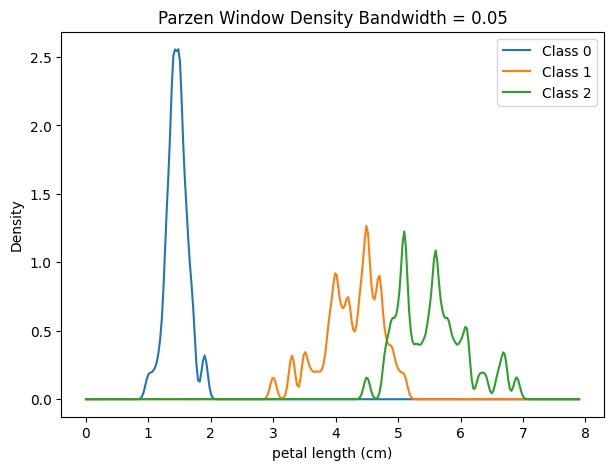

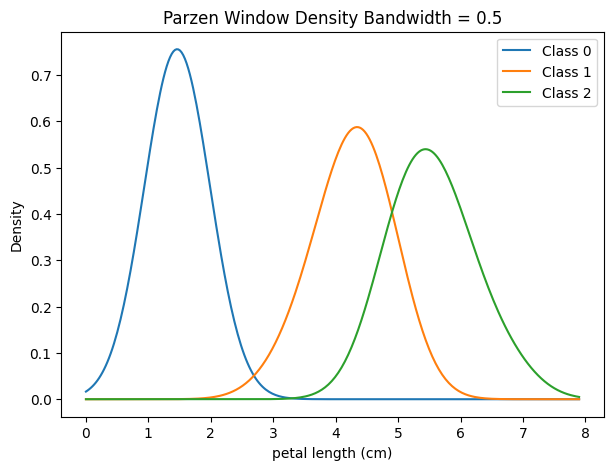

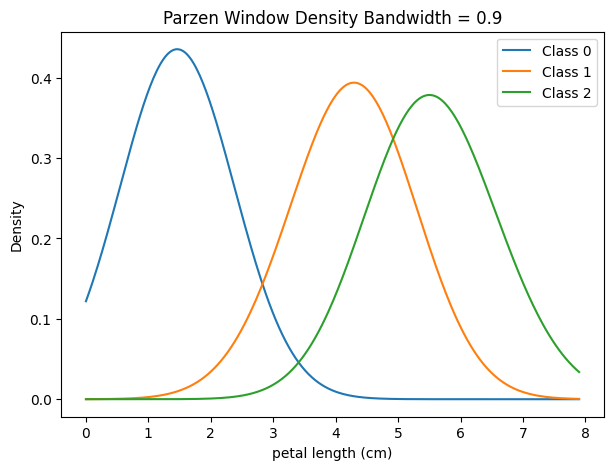

In [283]:
# TODO 10.3: Plot Parzen density estimates for different bandwidths
for i in bandwidths:
    plt.figure(figsize=(7, 5))
    for j in labels:
        data1 = Iris_DataFrame[Iris_DataFrame[target_name] == j][feature_name].values
        parzen = ParzenWindow1D(bandwidth=i)
        parzen.fit(data1)
        density =parzen.predict_density(grid)
        plt.plot(grid, density, label=f"Class {j}")

    plt.title(f"Parzen Window Density Bandwidth = {i}")
    plt.xlabel(feature_name)
    plt.ylabel("Density")
    plt.legend()
    plt.show()


### explain how small and large bandwidth values affect bias and variance
<div dir="rtl" align="right">
در Parzen Window مقدار bandwidth میزان هموار بودن تخمین چگالی را کنترل می‌ کند.
Bandwidth کوچک باعث می‌شود نمودار جزئیات داده را زیاد دنبال کند پس bias کم و variance زیاد می ‌شود و احتمال overfitting بالا می‌ رود.

Bandwidth بزرگ نمودار را خیلی هموار می‌ کند پس bias زیاد و variance کم می‌ شود و ممکن است جزئیات مهم داده از بین برود.
<div>

## Question 11(10pts)

Use 5-fold cross-validation to select the bandwidth. Use average log-likelihood as the selection criterion.

Plot log-likelihood versus bandwidth and identify the best bandwidth.

### Hint
For each fold, estimate the density of the validation samples using the training samples, then compute the average log-density.


In [302]:
# TODO 11.1: Define average log-likelihood for Parzen estimator
def log_likelihood(Xtrain, Xvalidation, bandwidth):
    Xtrain = Xtrain.ravel()
    Xvalidation =Xvalidation.ravel()

    densities = []
    for x in Xvalidation:
        u =(x - Xtrain) /bandwidth
        kernel = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
        density = np.mean(kernel) /bandwidth
        densities.append(density)

    densities = np.array(densities)
    densities= np.maximum(densities, 1e-10)
    return np.mean(np.log(densities))


In [309]:
# TODO 11.2: Define bandwidth selection function
def bandwidth_cv(X, bandwidths, n_splits =5):
    N_samples = len(X)
    c = np.arange(N_samples)
    np.random.seed(60)
    np.random.shuffle(c)

    f2 = np.array_split(c, n_splits)

    avg_log_likelihoods = []

    for bandwidth in bandwidths:
        f2_scores =[]
        for i in range(n_splits):
            validation_i = f2[i]
            train_i = np.concatenate([
                f2[j] for j in range(n_splits) if j!= i
            ])

            Xtrain = X[train_i]
            Xvalidation = X[validation_i]
            score = log_likelihood(Xtrain, Xvalidation, bandwidth)
            f2_scores.append(score)
        avg_log_likelihoods.append(np.mean(f2_scores))

    return np.array(avg_log_likelihoods)

In [ ]:
# TODO 11.3: Run bandwidth selection
X = Iris.data[:, 2].reshape(-1, 1)
bandwidths = np.linspace(0.05, 1.5, 30)
log_likelihoods = bandwidth_cv(X, bandwidths, n_splits =5)

Best bandwidth: 0.2
Best average log-likelihood: -1.4466876901134718


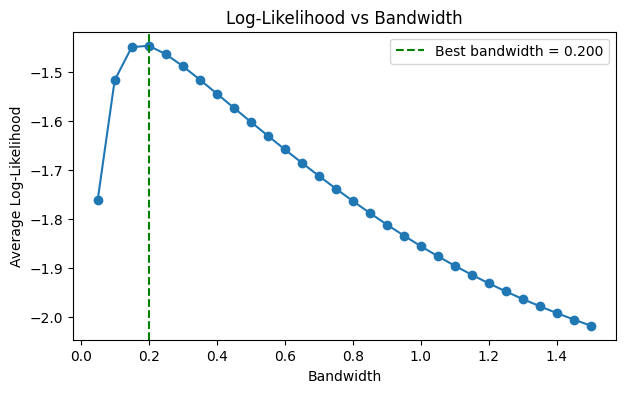

In [320]:
# TODO 11.4: Find and plot the best bandwidth
best_i = np.argmax(log_likelihoods)
best_bandwidth = bandwidths[best_i]

print("Best bandwidth:", best_bandwidth)
print("Best average log-likelihood:", log_likelihoods[best_i])

plt.figure(figsize=(7, 4))
plt.plot(bandwidths, log_likelihoods, marker='o')
plt.axvline(best_bandwidth, color='green', linestyle='--',label=f'Best bandwidth = {best_bandwidth:.3f}')

plt.xlabel("Bandwidth")
plt.ylabel("Average Log-Likelihood")
plt.title("Log-Likelihood vs Bandwidth")
plt.legend()
plt.show()



# Part 9: Density Estimation with Gaussian Mixture Model

## Question 12(10pts)

Using the two selected features `petal length (cm)` and `petal width (cm)`, train GMM models with 1 to 8 components.

For each model, compute AIC and BIC. Then use the AIC/BIC plots to select a suitable number of components.

### Hint
AIC and BIC are criteria that trade off model fit and model complexity. Lower values are usually better.


In [321]:
# TODO 12.1: Select features for GMM
X_GMM = Iris.data[:, [2, 3]]

In [ ]:
# TODO 12.2: Fit GMM models with different numbers of components
components = np.arange(1, 9)

AIC_V = []
BIC_V = []
models = []

for k in components:
    GMM= GaussianMixture(
        n_components =k,
        covariance_type='full',
        random_state =60
    )
    
    GMM.fit(X_GMM)

    AIC_V.append(GMM.aic(X_GMM))
    BIC_V.append(GMM.bic(X_GMM))
    models.append(GMM)

In [329]:
# TODO 12.3: Select best model based on AIC and BIC
best_AIC_i = np.argmin(AIC_V)
best_BIC_i = np.argmin(BIC_V)
best_AIC_components= components[best_AIC_i]
best_BIC_components = components[best_BIC_i]

print("Best number of components based on AIC:",best_AIC_components)
print("Best AIC:", AIC_V[best_AIC_i])
print("Best number of components based on BIC:", best_BIC_components)
print("Best BIC:", BIC_V[best_BIC_i])

Best number of components based on AIC: 4
Best AIC: 300.3118765406714
Best number of components based on BIC: 3
Best BIC: 355.8733918391297


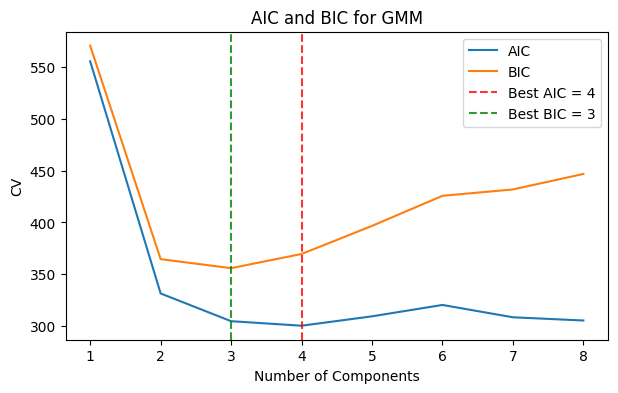

In [344]:
# TODO 12.4: Plot AIC and BIC
plt.figure(figsize=(7, 4))

plt.plot(components,AIC_V, label='AIC')
plt.plot(components, BIC_V,label='BIC')
plt.axvline(best_AIC_components, color='red', linestyle='--', alpha=0.8, label=f'Best AIC = {best_AIC_components}')
plt.axvline(best_BIC_components, color='green', linestyle='--',alpha=0.8, label=f'Best BIC = {best_BIC_components}')

plt.xlabel("Number of Components")
plt.ylabel("CV")
plt.title("AIC and BIC for GMM")
plt.xticks(components)
plt.legend()
plt.show()

## Question 13(bonus)(10pts)


Train the GMM selected based on BIC using the two selected features. Then:

1. plot the training points in the two-dimensional feature space;
2. draw the density contours estimated by the GMM;
3. explain whether the selected number of components is consistent with the three-class structure of Iris.


In [348]:
# TODO 13.1: Train the selected GMM
best_GMM = GaussianMixture(n_components= best_BIC_components,covariance_type='full', random_state =60)
best_GMM.fit(X_GMM)

,"n_components n_components: int, default=1The number of mixture components.",np.int64(3)
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",60


In [351]:
# TODO 13.2: Create a grid for density visualization
xMin,xMax = X_GMM[:,0].min() -1, X_GMM[:,0].max()+ 1
yMin, yMax = X_GMM[:,1].min() - 1, X_GMM[:, 1].max() +1
xx, yy = np.meshgrid(np.linspace(xMin, xMax, 200), np.linspace(yMin,yMax, 200))

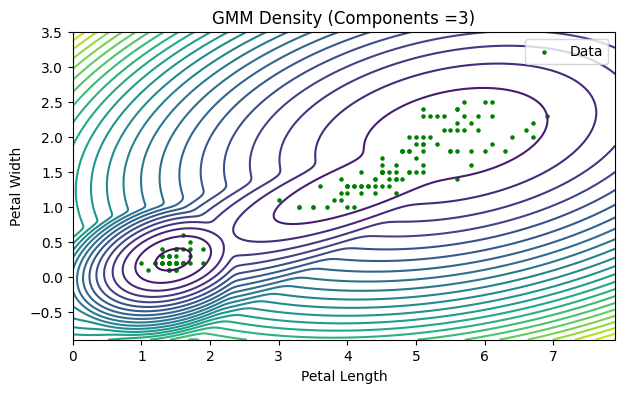

In [362]:
# TODO 13.3: Plot data and GMM density contours
Z = -best_GMM.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(7, 4))
plt.scatter(X_GMM[:, 0], X_GMM[:, 1], c='green', s= 5, label='Data')
plt.contour(xx, yy, Z, levels= 30, cmap='viridis')
plt.title(f'GMM Density (Components ={best_BIC_components})')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show()


### explain whether the selected number of components is consistent with the three-class structure of Iris
<div dir="rtl" align="right">
تعداد مولفه های انتخاب شده توسط BIC معمولا بین ۲ تا ۴ متغیر است. اگر BIC عدد ۳ را پیشنهاد داده باشد، کاملا با سه گونه‌ ی Iris سازگار است و هر مولفه یک خوشه برای هر گونه را نشان می‌ دهد. اگر عدد متفاوتی انتخاب شده باشد، به این دلیل است که برخی گونه‌ ها (مانند Versicolor و Virginica) در فضای ویژگی‌ ها هم‌ پوشانی زیادی دارند و ممکن است مدل برای تخمین بهتر توزیع چگالی داده‌ های هم‌ پوشانی شده آنها را به خوشه‌ های کوچک‌تری تقسیم کرده باشد یا چند گونه را در یک مولفه ترکیب کرده باشد.
<div>